# Assignment Solution: DA-AG-013 (Python Alternative)

**Subject:** Introduction to Power BI, Charts, DAX & Creating Reports  
**Assignment Code:** DA-AG-013  
**Total Marks:** 200  

--- 

**Note to Student:** 
Since you do not have access to Power BI software, this notebook uses **Python (Pandas & Matplotlib)** to simulate the required visuals and calculations. 

**Instructions:**
1.  **Theory (Q1-Q5):** Copy the written answers below to your submission document.
2.  **Practical (Q6-Q10):** Run the Python code blocks. Take **screenshots** of the resulting charts and numbers. Paste these screenshots into your assignment PDF as your solution visuals.

## Question 1: Define Power BI and its key components.

**Answer:**

**Power BI** is a collection of software services, apps, and connectors that work together to turn unrelated sources of data into coherent, visually immersive, and interactive insights. It allows users to visualize data, share discoveries, and collaborate on reports.

**Key Components:**

1.  **Power BI Desktop:** 
    A free Windows application where you connect to data, transform it, create data models, and build reports using visuals. This is the development environment.

2.  **Power BI Service (SaaS):** 
    A cloud-based service (`app.powerbi.com`) where you publish reports created in Desktop. It allows for sharing, collaboration, creating dashboards, and setting up automated data refreshes.

3.  **Power BI Mobile:** 
    Mobile apps for Windows, iOS, and Android that allow users to view and interact with reports and dashboards on the go.

4.  **Power BI Gateway:** 
    bridge software that acts as a secure transfer channel between on-premises data (like a local SQL server or Excel file) and the cloud-based Power BI Service, enabling data refreshes without moving the actual database to the cloud.

## Question 2: Compare Power BI visuals (Pie vs Donut, Bar vs Column).

**Answer:**

**1. Pie Chart vs. Donut Chart:**
* **Similarity:** Both show the relationship of parts to a whole (percentages).
* **Difference:** A Donut chart has a hollow center, which can be used to display a KPI, a total number, or a label, making it slightly more space-efficient for design.
* **Example:** Use a **Pie Chart** to show the gender distribution (Male/Female) of customers. Use a **Donut Chart** to show Sales by Region, placing the "Total Sales" text in the center hole.

**2. Bar Chart vs. Column Chart:**
* **Similarity:** Both compare categorical data using rectangular bars.
* **Difference:** 
    * **Column Charts** have vertical bars. They are best when you have few categories or time-based data (e.g., Sales over Years).
    * **Bar Charts** have horizontal bars. They are superior when category names are long (labels are easier to read) or when you have many categories.
* **Example:** Use a **Column Chart** for "Sales by Year" (2020, 2021, 2022). Use a **Bar Chart** for "Sales by Product Name" (where names like "Logitech Wireless Mouse" would fit better horizontally).

## Question 3: Explain Star Schema vs Snowflake Schema, Keys, and Cardinality.

**Answer:**

**1. Star Schema vs. Snowflake Schema:**
* **Star Schema:** The simplest model. It has a central **Fact Table** (transactions) directly connected to multiple **Dimension Tables** (attributes). It resembles a star shape. *Best for Power BI performance.*
* **Snowflake Schema:** An extension of the Star schema where dimension tables are normalized (broken down) into further tables (e.g., Product Table -> Category Table -> Sub-Category Table). It is more complex and can be slower in Power BI.

**2. Primary Key vs. Foreign Key:**
* **Primary Key (PK):** A unique identifier for every row in a table (e.g., `Product ID` in the Product Table).
* **Foreign Key (FK):** A field in a table that refers to the Primary Key of another table (e.g., `Product ID` in the Sales Table). The relationship is built by connecting the PK to the FK.

**3. Cardinality:**
* Cardinality defines the nature of the relationship between two tables (e.g., One-to-One, One-to-Many, Many-to-Many). 
* **Importance:** It tells Power BI how to filter data. A **One-to-Many** relationship (e.g., One Product has Many Sales) is the ideal standard for correct calculations. Incorrect cardinality setting results in wrong totals and performance issues.

## Question 4: Calculated Column vs Measure, Row vs Filter Context.

**Answer:**

**1. Calculated Column vs. Measure:**
* **Calculated Column:** Evaluated row-by-row *when the data is loaded*. The result is stored in the table RAM. 
    * *Example:* `Profit = Sales - Cost` (calculated for every single transaction row).
* **Measure:** Evaluated on the fly *when used in a visual*. It depends on the user's interaction (slicers/filters). It is not stored in the database.
    * *Example:* `Total Sales = SUM(Sales[Amount])`.

**2. Row Context vs. Filter Context:**
* **Row Context:** The concept of "current row." If you write a formula `[Price] * [Quantity]`, Power BI knows to look at the Price and Quantity in the *same row*.
* **Filter Context:** The set of filters applied to the data at any given moment (e.g., by Slicers, Visual interactions, or Calculate modifiers). If you select "Year 2023" in a slicer, the Filter Context for the calculation becomes "Year = 2023".

## Question 5: Difference between a Report and a Dashboard in Power BI.

**Answer:**

| Feature | Report | Dashboard |
| :--- | :--- | :--- |
| **Definition** | A detailed multi-page view of data with interactive visuals. | A single-page canvas (Canvas) summarizing key metrics. |
| **Source** | Created in Power BI Desktop or Service. | Created only in Power BI Service (using pinned visuals from reports). |
| **Interactivity** | Highly interactive (slicing, drilling down). | Limited interactivity (clicking a tile usually takes you to the underlying report). |
| **Pages** | Can have multiple pages. | Single page only. |
| **Purpose** | Deep dive analysis. | High-level monitoring / "At a glance" view. |

## Question 6: Practical - Sales Charts (Global Superstore)
**Goal:** Create a Clustered Bar Chart (Sales by Sub-Category) and a Donut Chart (Sales % by Region).

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_15524\1521470329.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_subcat.values, y=sales_by_subcat.index, ax=ax[0], palette="viridis")


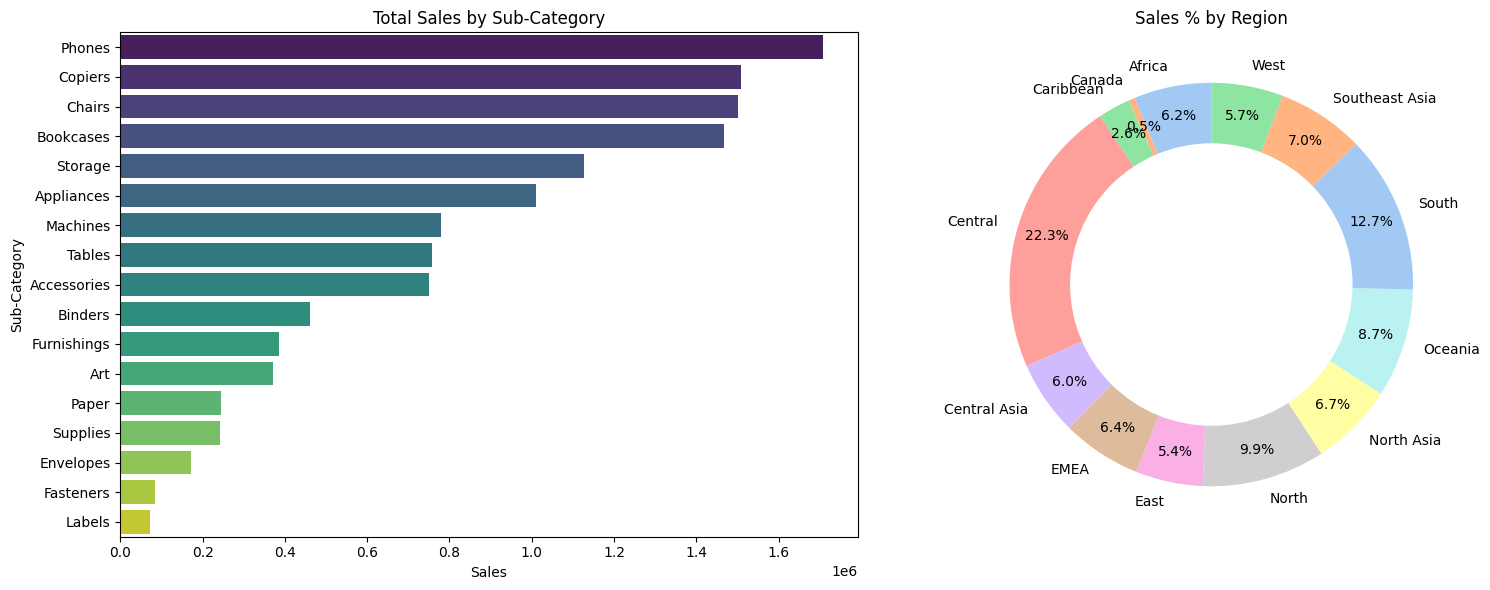

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df_superstore = pd.read_csv("Global_Superstore2.csv", encoding='latin1')

    # Setup plots
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Clustered Bar Chart: Total Sales by Sub-Category
    sales_by_subcat = df_superstore.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
    sns.barplot(x=sales_by_subcat.values, y=sales_by_subcat.index, ax=ax[0], palette="viridis")
    ax[0].set_title('Total Sales by Sub-Category')
    ax[0].set_xlabel('Sales')

    # 2. Donut Chart: Sales % by Region
    sales_by_region = df_superstore.groupby('Region')['Sales'].sum()
    # Create a pie chart
    wedges, texts, autotexts = ax[1].pie(sales_by_region, labels=sales_by_region.index, autopct='%1.1f%%', 
                                         startangle=90, pctdistance=0.85, colors=sns.color_palette("pastel"))
    # Draw a circle at the center to turn Pie into Donut
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax[1].add_artist(centre_circle)
    ax[1].set_title('Sales % by Region')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Dataset 'Global_Superstore2.csv' not found. Please upload the file.")

## Question 7: Practical - KPIs and Trend Analysis
**Goal:** KPI Cards for Total Profit & Avg Discount, and a Line Chart for Profit Trend.

--- KPI CARDS ---
Total Profit: $1,467,457.29
Average Discount: 14.29%


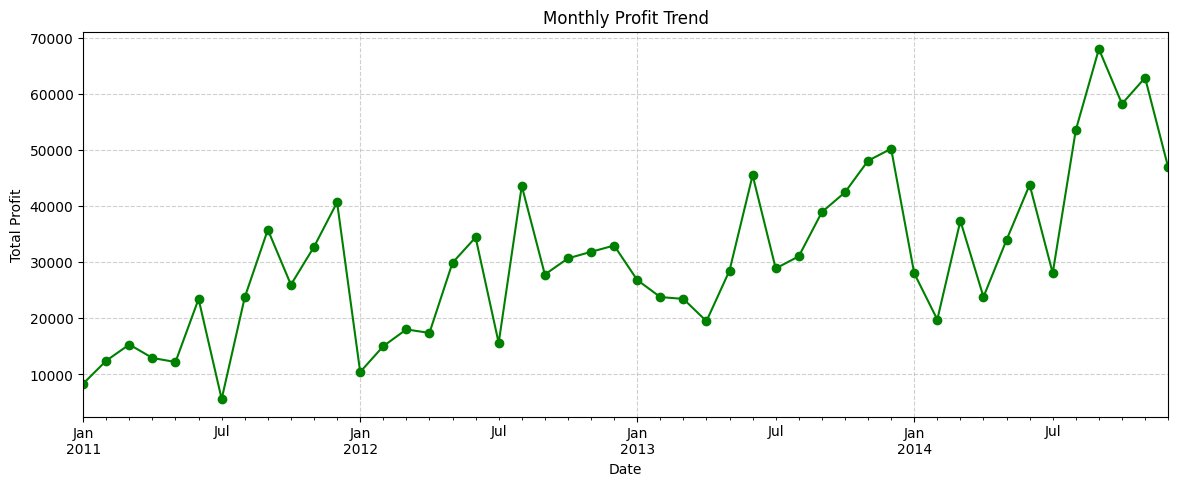

In [2]:
# KPI Calculations
total_profit = df_superstore['Profit'].sum()
avg_discount = df_superstore['Discount'].mean()

print(f"--- KPI CARDS ---")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Discount: {avg_discount*100:.2f}%")

# Line Chart: Profit Trend Over Months
# Convert Order Date to datetime
df_superstore['Order Date'] = pd.to_datetime(df_superstore['Order Date'], dayfirst=True, errors='coerce')
df_superstore['Month_Year'] = df_superstore['Order Date'].dt.to_period('M')

# Group by Month
profit_trend = df_superstore.groupby('Month_Year')['Profit'].sum()

# Plot
plt.figure(figsize=(14, 5))
profit_trend.plot(marker='o', color='green')
plt.title('Monthly Profit Trend')
plt.xlabel('Date')
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Question 8: DAX Measure Simulation - % of Total Sales by Category

In [3]:
# Calculate Total Sales overall
grand_total_sales = df_superstore['Sales'].sum()

# Group by Category
category_sales = df_superstore.groupby('Category')[['Sales']].sum()

# Calculate Percentage (Simulating the DAX DIVIDE function)
category_sales['% of Total Sales'] = (category_sales['Sales'] / grand_total_sales) * 100

# Display Table
print("--- Sales Percentage by Category ---")
print(category_sales.round(2))

--- Sales Percentage by Category ---
                      Sales  % of Total Sales
Category                                     
Furniture        4110874.19             32.52
Office Supplies  3787070.23             29.96
Technology       4744557.50             37.53


## Question 9: Profit Analysis by Sub-Category
**Goal:** Analyze how different Sub-Categories contribute to overall profit (Simulating Waterfall Chart insights).

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_15524\177824567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_sub.index, y=profit_by_sub.values, palette=colors)


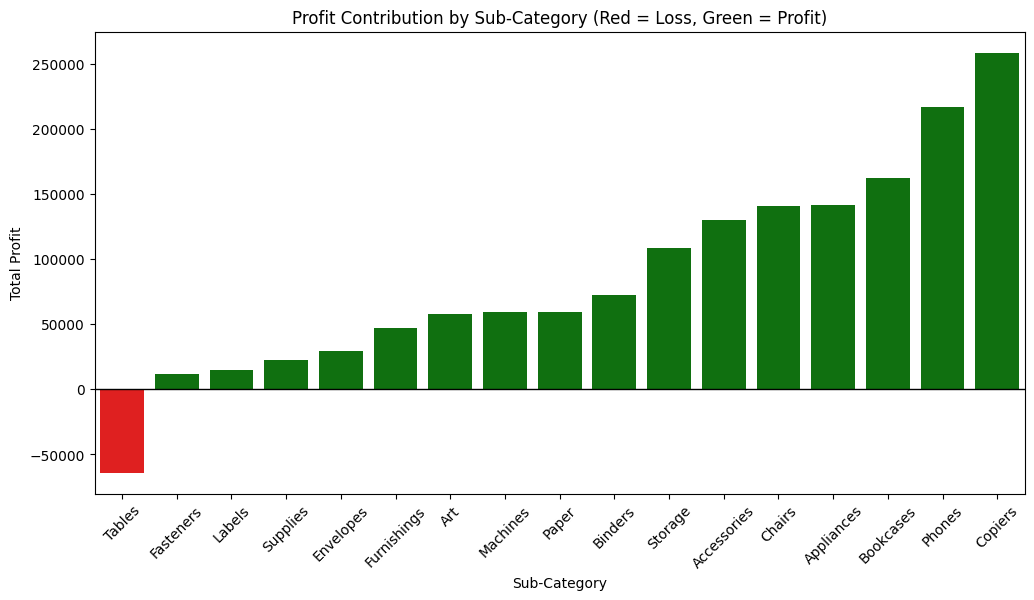

Business Insight: The 'Tables' sub-category is generating a significant loss, negatively impacting overall profitability, while 'Copiers' and 'Phones' are the highest contributors.


In [4]:
# Calculate Profit by Sub-Category
profit_by_sub = df_superstore.groupby('Sub-Category')['Profit'].sum().sort_values()

# Create colors: Red for negative profit, Green for positive
colors = ['red' if x < 0 else 'green' for x in profit_by_sub.values]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=profit_by_sub.index, y=profit_by_sub.values, palette=colors)
plt.title('Profit Contribution by Sub-Category (Red = Loss, Green = Profit)')
plt.xticks(rotation=45)
plt.ylabel('Total Profit')
plt.axhline(0, color='black', linewidth=1)
plt.show()

print("Business Insight: The 'Tables' sub-category is generating a significant loss, negatively impacting overall profitability, while 'Copiers' and 'Phones' are the highest contributors.")

## Question 10: Scenario - Vita Track Wellness Dashboard
**Goal:** Build a dashboard view answering health insights.

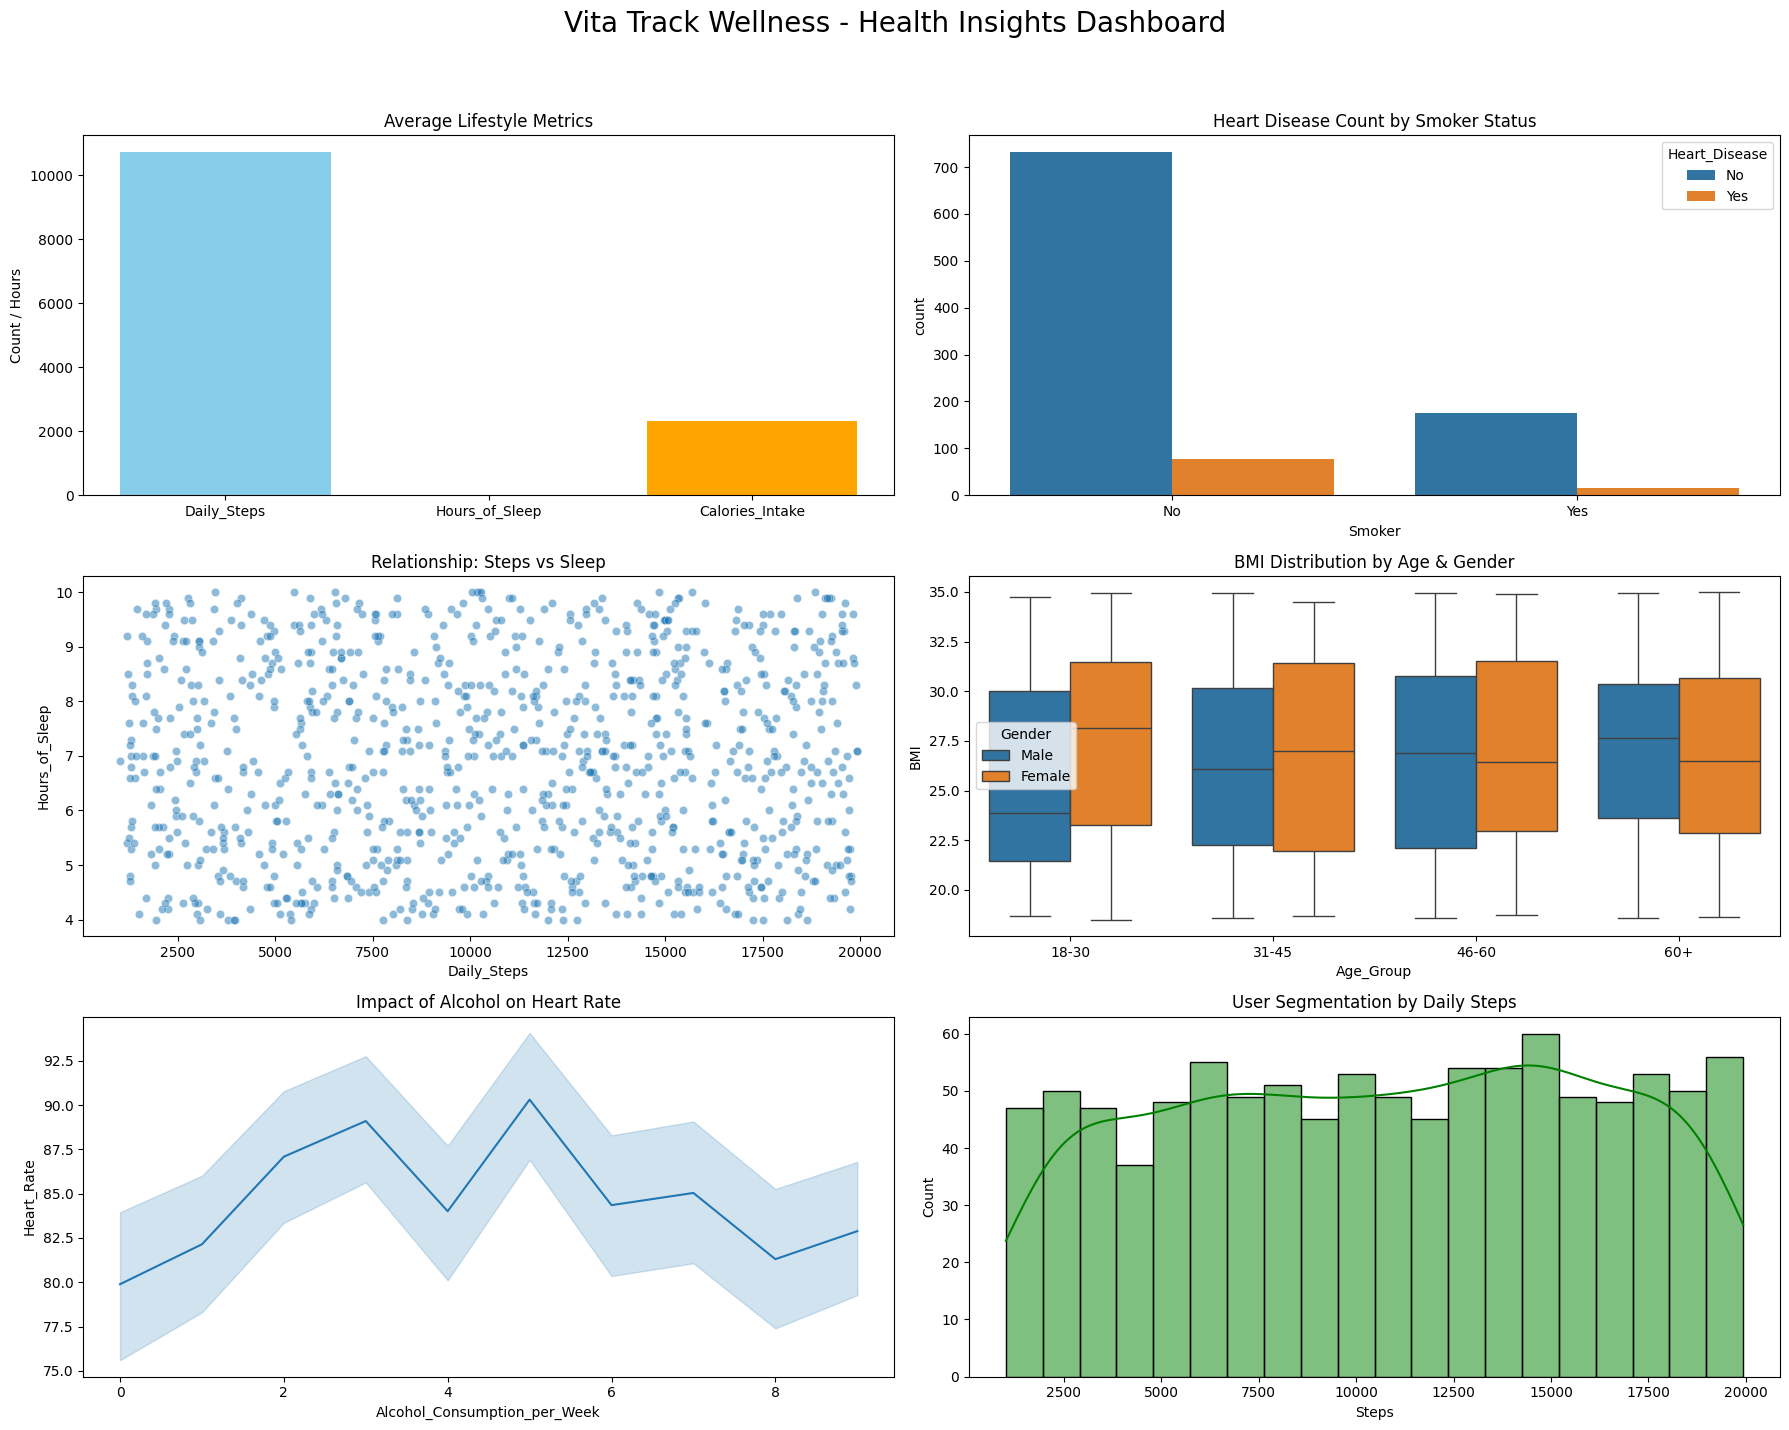

In [5]:
try:
    df_health = pd.read_csv("health_activity_data.csv")
    
    # Setup a dashboard grid (3 Rows, 2 Columns)
    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    plt.suptitle('Vita Track Wellness - Health Insights Dashboard', fontsize=20)

    # 1. Balanced Lifestyle (Avg Metrics)
    lifestyle_metrics = df_health[['Daily_Steps', 'Hours_of_Sleep', 'Calories_Intake']].mean()
    axes[0, 0].bar(lifestyle_metrics.index, lifestyle_metrics.values, color=['skyblue', 'purple', 'orange'])
    axes[0, 0].set_title('Average Lifestyle Metrics')
    axes[0, 0].set_ylabel('Count / Hours')

    # 2. Heart Disease Risk by Smoker Status
    sns.countplot(x='Smoker', hue='Heart_Disease', data=df_health, ax=axes[0, 1])
    axes[0, 1].set_title('Heart Disease Count by Smoker Status')

    # 3. Sleep vs Physical Activity (Scatter)
    sns.scatterplot(x='Daily_Steps', y='Hours_of_Sleep', data=df_health, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].set_title('Relationship: Steps vs Sleep')

    # 4. BMI by Age Group (Need to bin age first)
    df_health['Age_Group'] = pd.cut(df_health['Age'], bins=[18, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
    sns.boxplot(x='Age_Group', y='BMI', hue='Gender', data=df_health, ax=axes[1, 1])
    axes[1, 1].set_title('BMI Distribution by Age & Gender')

    # 5. Impact of Alcohol on Heart Rate
    sns.lineplot(x='Alcohol_Consumption_per_Week', y='Heart_Rate', data=df_health, ax=axes[2, 0])
    axes[2, 0].set_title('Impact of Alcohol on Heart Rate')

    # 6. Activity Segmentation (Histogram of Steps)
    sns.histplot(df_health['Daily_Steps'], bins=20, kde=True, color='green', ax=axes[2, 1])
    axes[2, 1].set_title('User Segmentation by Daily Steps')
    axes[2, 1].set_xlabel('Steps')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
    plt.show()
    
except FileNotFoundError:
    print("Dataset 'health_activity_data.csv' not found.")